In [17]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from pylab import rcParams
rcParams['figure.figsize'] = 10, 8
rcParams['figure.dpi'] = 300

import torch
from torch import nn
from torch import distributions
from torch.nn.parameter import Parameter

from sklearn import datasets

In [18]:
class RealNVP(nn.Module):
    def __init__(self, dim, nets, nett, masks, prior):
        super().__init__()
        self.dim = int(dim)
        self.prior = prior

        if masks.ndim != 2 or masks.shape[1] != self.dim:
            raise ValueError(f"masks must have shape (num_coupling_layers, {self.dim})")

        self.mask = Parameter(masks, requires_grad=False)
        self.num_coupling_layers = masks.shape[0]
        self.t = nn.ModuleList([nett() for _ in range(self.num_coupling_layers)])
        self.s = nn.ModuleList([nets() for _ in range(self.num_coupling_layers)])

    def g(self, z):
        x = z
        for i in range(self.num_coupling_layers):
            mask = self.mask[i]
            x_ = x * mask
            s = self.s[i](x_) * (1 - mask)
            t = self.t[i](x_) * (1 - mask)
            x = x_ + (1 - mask) * (x * torch.exp(s) + t)
        return x

    def f(self, x):
        log_det_J = x.new_zeros(x.shape[0])
        z = x
        for i in reversed(range(self.num_coupling_layers)):
            mask = self.mask[i]
            z_ = z * mask
            s = self.s[i](z_) * (1 - mask)
            t = self.t[i](z_) * (1 - mask)
            z = z_ + (1 - mask) * (z - t) * torch.exp(-s)
            log_det_J -= s.sum(dim=1)
        return z, log_det_J

    def log_prob(self, x):
        z, log_det_J = self.f(x)
        return self.prior.log_prob(z) + log_det_J

    def sample(self, batch_size):
        z = self.prior.sample((batch_size,))
        return self.g(z)

In [20]:
def build_masks(dim, depth=3, dtype=torch.float32, device=None):
    if dim < 2:
        raise ValueError("dim must be at least 2")

    if dim % 2 == 0:
        masks = np.array([[1, 0] * (dim // 2), [0, 1] * (dim // 2)] * depth)
    else:
        masks = np.zeros((dim * depth, dim), dtype=np.float32)
        for i in range(dim * depth):
            masks[i, i % dim] = 1
    return torch.as_tensor(masks, dtype=dtype, device=device)


def build_prior(dim=2, prior_std=1.0, prior_mean=0.0, dtype=torch.float32, device=None):
    loc = torch.full((dim,), prior_mean, dtype=dtype, device=device)
    covariance_matrix = torch.eye(dim, dtype=dtype, device=device) * prior_std ** 2
    return distributions.MultivariateNormal(loc, covariance_matrix)


def build_model(device, dim=2, width=32, depth=3, scale=1.0, prior=None, dtype=torch.float32):
    def make_net(use_tanh=False):
        layers = [
            nn.Linear(dim, width),
            nn.LeakyReLU(),
            nn.Linear(width, width),
            nn.LeakyReLU(),
            nn.Linear(width, dim),
        ]
        if use_tanh:
            layers.append(nn.Tanh())
        net = nn.Sequential(*layers).to(dtype=dtype)
        for layer in net:
            if isinstance(layer, nn.Linear):
                layer.weight.data.mul_(scale)
                layer.bias.data.mul_(scale)
        return net

    nets = lambda: make_net(use_tanh=True)
    nett = lambda: make_net(use_tanh=False)
    masks = build_masks(dim, depth, dtype=dtype, device=device)

    if prior is None:
        prior = build_prior(dim=dim, dtype=dtype, device=device)

    return RealNVP(dim, nets, nett, masks, prior).to(device)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dim = 2
prior = build_prior(dim=dim, device=device)
flow = build_model(device, dim=dim, width=256, depth=3, prior=prior)

In [ ]:
optimizer = torch.optim.Adam([p for p in flow.parameters() if p.requires_grad], lr=1e-4)
model_dtype = next(flow.parameters()).dtype
for t in range(5001):
    noisy_moons = datasets.make_moons(n_samples=100, noise=.05)[0].astype(np.float32)
    batch = torch.from_numpy(noisy_moons).to(device=device, dtype=model_dtype)
    loss = -flow.log_prob(batch).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 500 == 0:
        print('iter %s:' % t, 'loss = %.3f' % loss.item())

iter 0: loss = 2.697
iter 500: loss = 0.582
iter 1000: loss = 0.519
iter 1500: loss = 0.529
iter 2000: loss = 0.510
iter 2500: loss = 0.423
iter 3000: loss = 0.332
iter 3500: loss = 0.515
iter 4000: loss = 0.487
iter 4500: loss = 0.397
iter 5000: loss = 0.247


Text(0.5, 1.0, '$X = g(z)$')

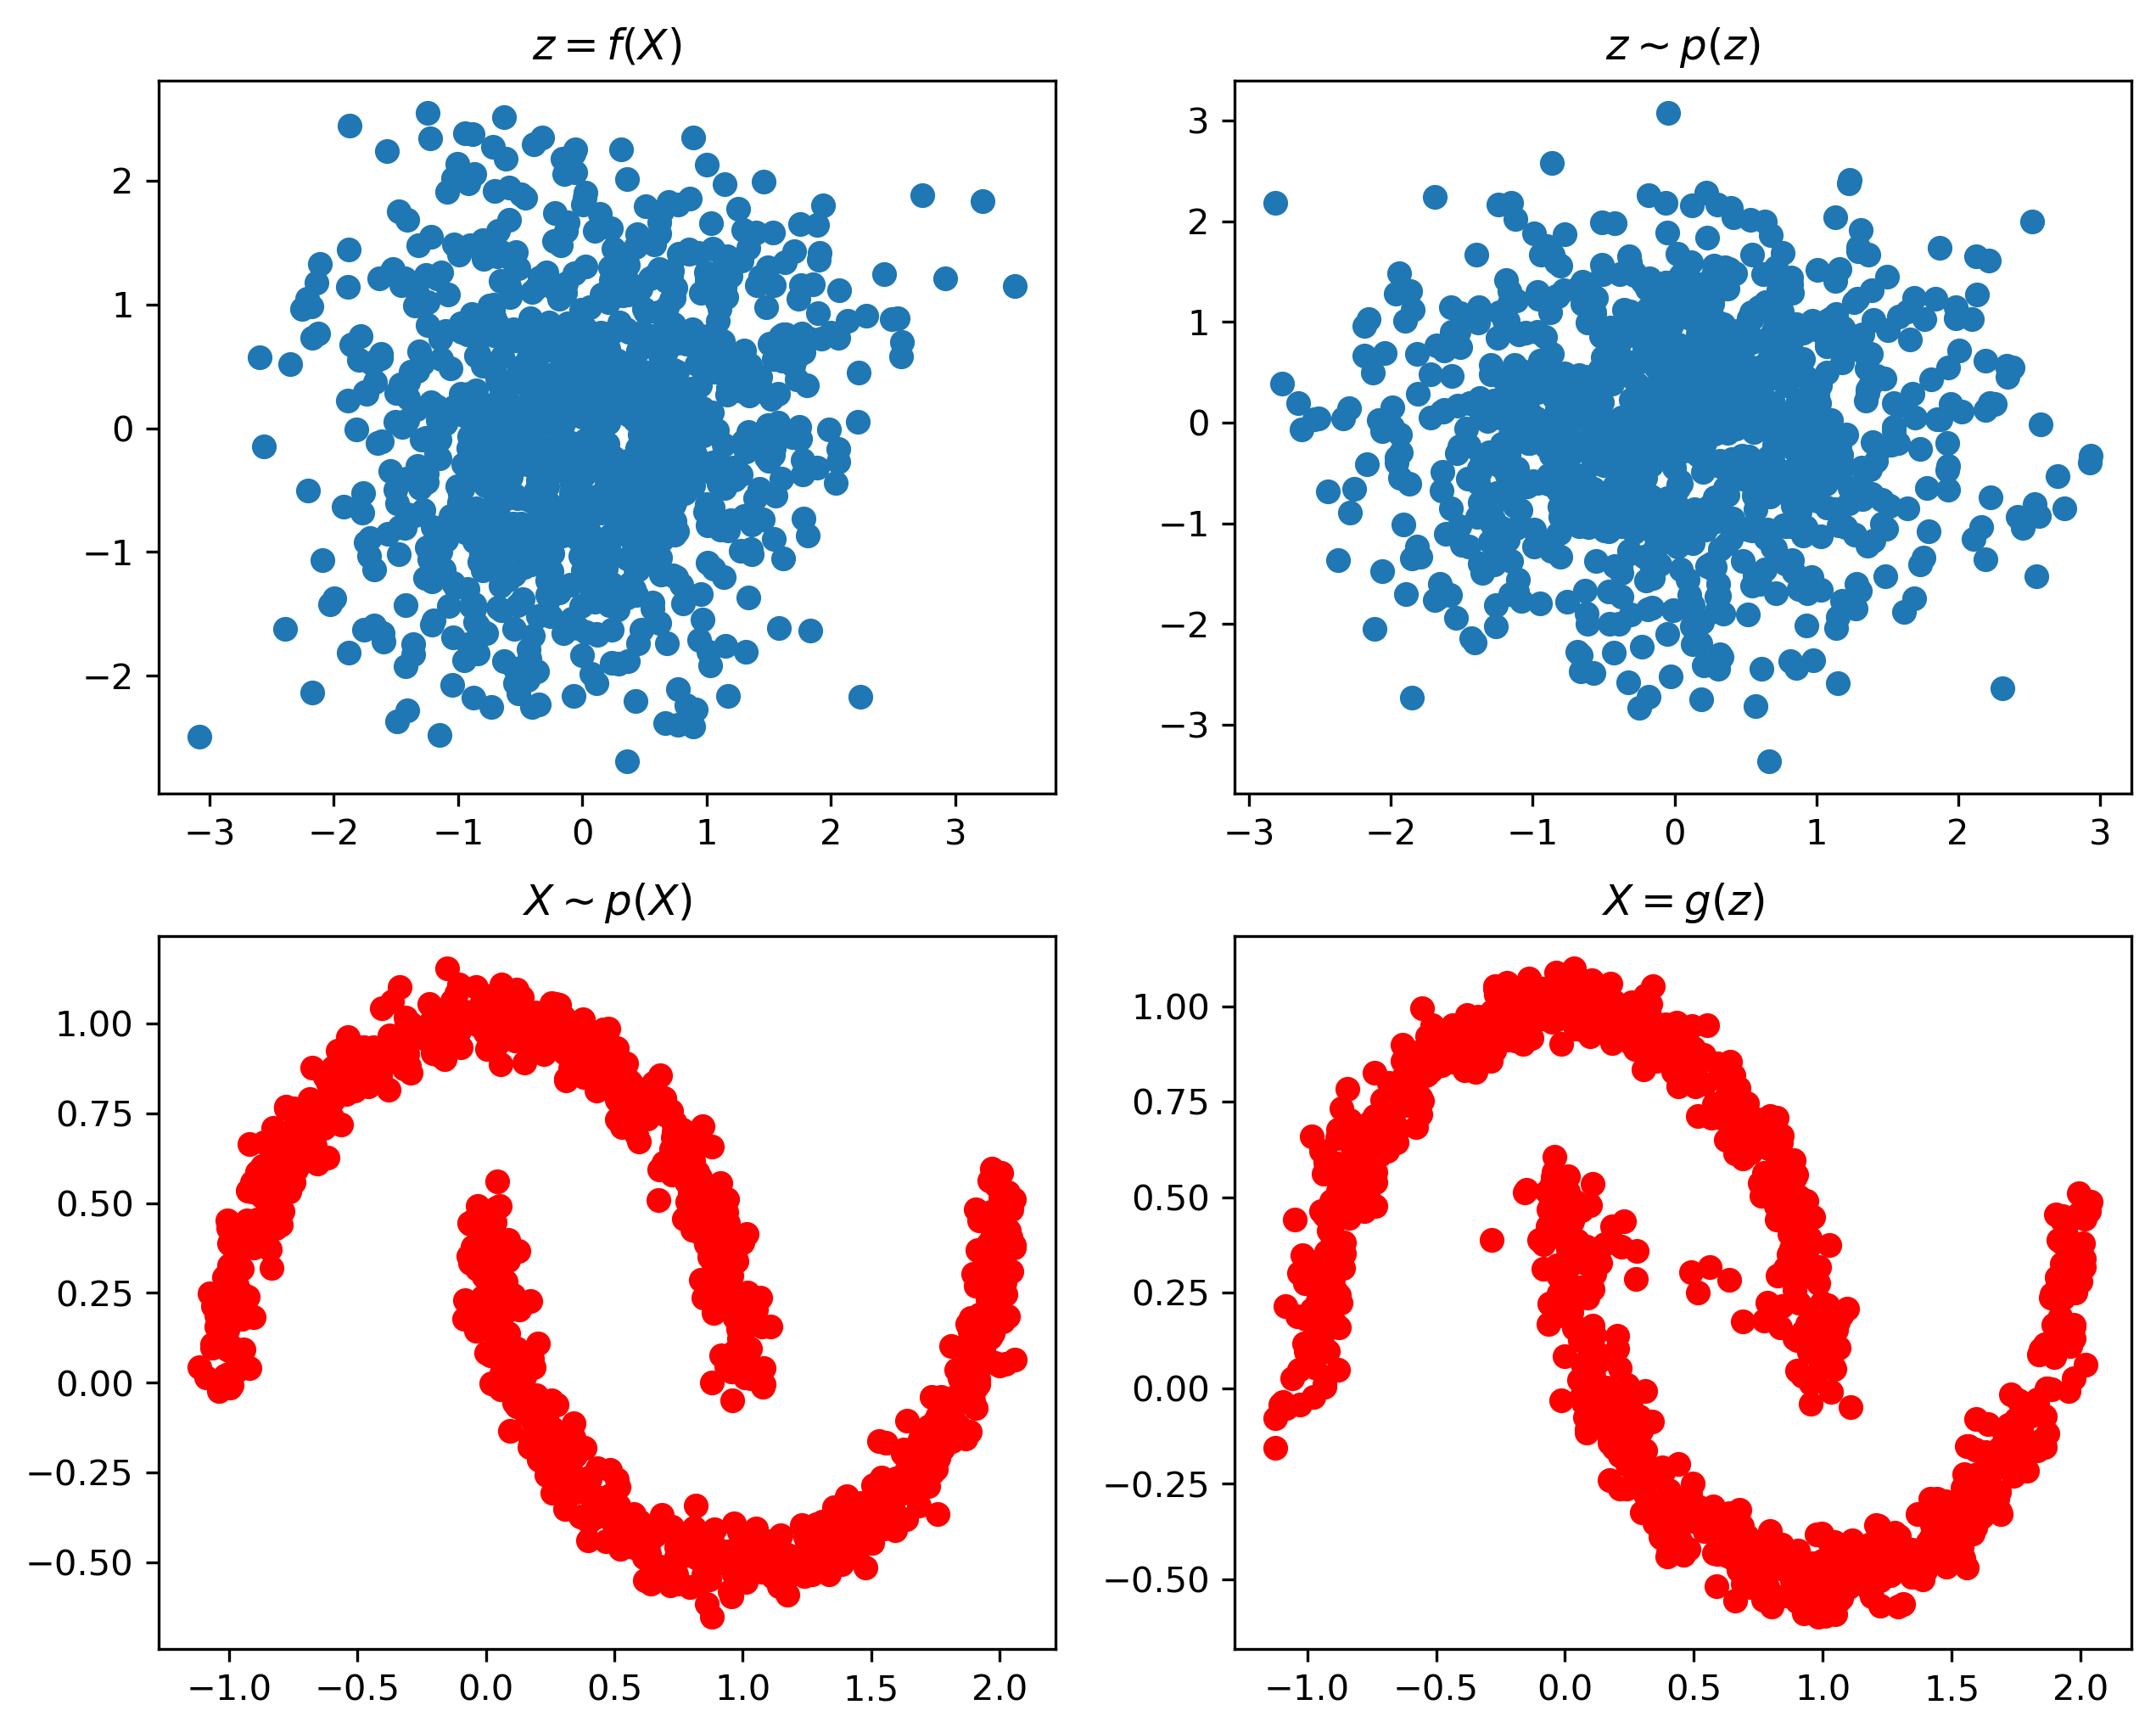

In [ ]:
noisy_moons = datasets.make_moons(n_samples=1000, noise=.05)[0].astype(np.float32)
batch = torch.from_numpy(noisy_moons).to(device=device, dtype=model_dtype)
z = flow.f(batch)[0].detach().cpu().numpy()
plt.subplot(221)
plt.scatter(z[:, 0], z[:, 1])
plt.title(r'$z = f(X)$')

z = prior.sample((1000,)).detach().cpu().numpy()
plt.subplot(222)
plt.scatter(z[:, 0], z[:, 1])
plt.title(r'$z \sim p(z)$')

plt.subplot(223)
x = datasets.make_moons(n_samples=1000, noise=.05)[0].astype(np.float32)
plt.scatter(x[:, 0], x[:, 1], c='r')
plt.title(r'$X \sim p(X)$')

plt.subplot(224)
x = flow.sample(1000).detach().cpu().numpy()
plt.scatter(x[:, 0], x[:, 1], c='r')
plt.title(r'$X = g(z)$')

torch.Size([4])
torch.Size([4])
torch.Size([4, 3])
